In [6]:
import numpy as np
import matplotlib.pylab as plt

imagepath = "C:\\Users\\User\\Documents\\Documents\\University\\Master_SU\\Year_1\\IIB\\CompAstro\\Projects\\Project3\\Plots\\"

In [7]:
def get_interface_flux(nzones,rho,speed,reconstruct):

    #arrays for the flux through the m+1/2 (Fmphalf) and the m-1/2 (Fmmhalf) interfaces
    Fmphalf = np.zeros(nzones)
    Fmmhalf = np.zeros(nzones)
    
    if reconstruct=='pc':
        if speed>0:
            Fmphalf[:] = speed*rho.copy()
            Fmmhalf[0] = speed*rho[-1].copy()
            Fmmhalf[1:] = speed*rho[:-1].copy()

        else:
            Fmphalf[:-1] = speed*rho[1:].copy()
            Fmphalf[-1] = speed*rho[0].copy()
            Fmmhalf[:] = speed*rho.copy()

    elif reconstruct=='tvd':
        if speed>0:
            rhom1 = np.zeros(len(rho))
            rhom1[0] = rho[-1]
            rhom1[1:] = rho[:-1]

            minslope = (rhom1-rho)
            pluslope = (rho-rhom1)

            for k in range(0, len(minslope)-1):
                signmin = np.sign(minslope[k])
                signplu = np.sign(pluslope[k])

                if signmin != signplu:
                    Fmphalf[k+1] = speed*rho[k].copy()

                else:
                    if signmin == 1 or signmin == 0:
                        slope = np.min(minslope[k], pluslope[k]) 
                    else:
                        slope = np.max(minslope[k], pluslope[k])

                    rhomin = rho[k] - 0.5*slope
                    rhoplu = rho[k] + 0.5*slope
                    Fmmhalf[k] = speed*rhomin
                    Fmphalf[k] = speed*rhoplu
        else:
            rhom1 = np.zeros(len(rho))
            rhom1[-1] = rho[0]
            rhom1[:-1] = rho[1:]

            pluslope = (rhom1-rho)
            minslope = (rho-rhom1)

            signmin = np.sign(minslope)
            signplu = np.sign(pluslope)

            for k in range(0, len(minslope)):
                if signmin[k] != signplu[k]:
                    Fmphalf[k-1] = speed*rho[k].copy()

                else:
                    slope = min(minslope[k], pluslope[k])
                    rhomin = rho[k] - 0.5*slope
                    rhoplu = rho[k] + 0.5*slope
                    Fmmhalf[k] = speed*rhoplu
                    Fmphalf[k] = speed*rhomin

    return Fmphalf,Fmmhalf

def evolve_advection_problem(nzones=50,xmin=0.0,xmax=1.0,speed=1.0,C=0.25,tend=1.0,IC='tophat',recon='pc',order=1):
    #construct grid
    dx = (xmax-xmin)/nzones
    x = np.linspace(xmin,xmax,nzones)+dx/2

    #set initial conditions
    rho = np.zeros(nzones)
    rho = np.exp(-((x-0.5)/0.2)**2)
    rho0 = rho.copy()

    time=0.0
    while time<tend:
        rhon = rho.copy()
        dt = C*dx/np.abs(speed)
        if time+dt>tend:
            dt = tend-time

        if order==1:
            #evolve density to full state (n) -> (n+1)
            Fmphalf,Fmmhalf = get_interface_flux(nzones, rhon, speed, recon) 
            rho[:] = ((Fmmhalf-Fmphalf)/dx) * dt + rhon
        
        elif order==2:
            rho1_2 = rho.copy()
            #first evolve density to half state (n) -> (n+1/2)
            Fmphalf,Fmmhalf = get_interface_flux(nzones, rhon, speed, recon)    
            rho1_2[:] = ((Fmmhalf-Fmphalf)/dx) * dt/2 + rhon
    
            #use (n+1/2) state to recalculated fluxes and evolve to full state (n) -> (n+1)    
            Fmphalf,Fmmhalf = get_interface_flux(nzones, rho1_2, speed, recon) 
            rho[:] = ((Fmmhalf-Fmphalf)/dx) * dt + rhon
        
        time = time + dt

    return x,rho,rho0

50 0.25 0.11519174923611285
100 0.25 0.06711412456533743
200 0.25 0.036716968034866015
400 0.25 0.01928709405509902
50 0.25 0.14006450827298622
100 0.25 0.08442664880771036
200 0.25 0.04735074474957607
400 0.25 0.02525834761501895


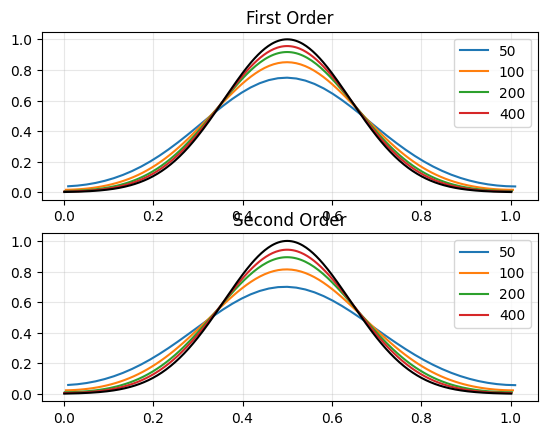

In [8]:
#solve the advection problem for varying grid sizes with pc reconstuction
#(first order spatial) and midpoint time stepping (second order time), find the convergence order
fig, (ax1, ax2) = plt.subplots(2,1)
C=0.25
Ns = [50,100,200,400]#,800,1600]
pc_error = np.zeros(len(Ns)*2).reshape(len(Ns),2)
count=0
for i in Ns:
    x,rho,rho0 = evolve_advection_problem(nzones=i,xmin=0.0,xmax=1.0,speed=1.0,C=C,tend=1.0,IC='gaussian',recon='pc',order=1)
    ax1.plot(x,rho, label=f"{i}")
    deltax = x[1]-x[0]
    L2norm = np.sqrt(np.sum((rho[:]-rho0[:])**2, axis=0)/i)
    pc_error[count,:] = (i,L2norm)
    print(i,C,L2norm)
    count += 1
ax1.plot(x,rho0,'k')
ax1.set_title("First Order")  
ax1.grid(alpha=0.3)  
ax1.legend()

count=0
for i in Ns:
    x,rho,rho0 = evolve_advection_problem(nzones=i,xmin=0.0,xmax=1.0,speed=1.0,C=C,tend=1.0,IC='gaussian',recon='pc',order=2)
    ax2.plot(x,rho, label=f"{i}")
    deltax = x[1]-x[0]
    L2norm = np.sqrt(np.sum((rho[:]-rho0[:])**2, axis=0)/i)
    pc_error[count,:] = (i,L2norm)
    print(i,C,L2norm)
    count += 1
ax2.plot(x, rho0, 'k')
ax2.set_title("Second Order")
ax2.grid(alpha=0.3)  
ax2.legend()

fig.savefig(imagepath+"2ndpcadv_ex2.pdf", dpi = 300, bbox_inches="tight")   

50 0.25 708563211013986.2
100 0.25 1.0445507307117452e+34
200 0.25 3.629202258951714e+72
400 0.25 7.288462476099148e+149
50 0.25 7.1794178416879176e+16
100 0.25 1.5026528410152845e+38
200 0.25 1.0516707487924144e+81


C:\Users\User\AppData\Local\Temp\ipykernel_2928\1094584687.py:26: RuntimeWarning: overflow encountered in square
  L2norm = np.sqrt(np.sum((rho[:]-rho0[:])**2, axis=0)/i)
C:\Users\User\AppData\Local\Temp\ipykernel_2928\1094584687.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend()


400 0.25 inf


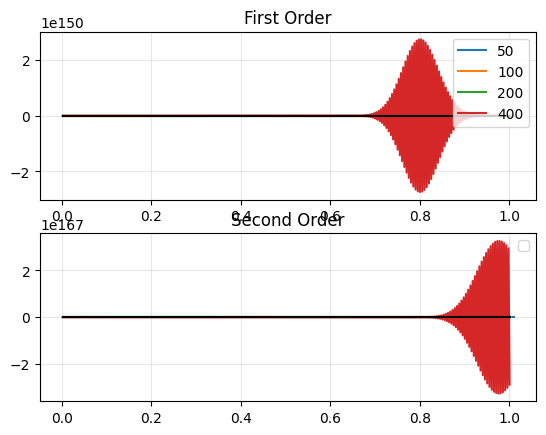

In [9]:
#solve the advection problem for varying grid sizes with tvd reconstuction
#(first order spatial) and midpoint time stepping (second order time), find the convergence order
fig2, (ax3, ax4) = plt.subplots(2,1)
C=0.25
Ns = [50,100,200,400]#,800,1600]
tvd_error = np.zeros(len(Ns)*2).reshape(len(Ns),2)
count=0
for i in Ns:
    x,rho,rho0 = evolve_advection_problem(nzones=i,xmin=0.0,xmax=1.0,speed=1.0,C=C,tend=1.0,IC='gaussian',recon='tvd',order=1)
    ax3.plot(x,rho, label=f"{i}")
    deltax = x[1]-x[0]
    L2norm = np.sqrt(np.sum((rho[:]-rho0[:])**2, axis=0)/i)
    tvd_error[count,:] = (i,L2norm)
    print(i,C,L2norm)
    count += 1
ax3.plot(x,rho0,'k')
ax3.set_title("First Order")
ax3.grid(alpha=0.3)
ax3.legend() 

count=0
for i in Ns:
    x,rho,rho0 = evolve_advection_problem(nzones=i,xmin=0.0,xmax=1.0,speed=1.0,C=C,tend=1.0,IC='gaussian',recon='tvd',order=2)
    ax4.plot(x,rho)
    deltax = x[1]-x[0]
    L2norm = np.sqrt(np.sum((rho[:]-rho0[:])**2, axis=0)/i)
    tvd_error[count,:] = (i,L2norm)
    print(i,C,L2norm)
    count += 1
ax4.plot(x,rho0,'k')
ax4.set_title("Second Order")
ax4.grid(alpha=0.3) 
ax4.legend()

fig2.savefig(imagepath+"2ndtvdadv_ex2.pdf", dpi = 300, bbox_inches="tight")

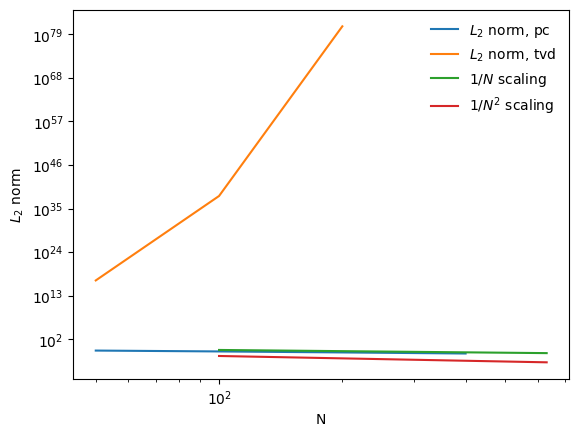

In [10]:
fig3, ax5 = plt.subplots(1,1)

ax5.plot(pc_error.T[0],pc_error.T[1],label="$L_2$ norm, pc")
ax5.plot(tvd_error.T[0],tvd_error.T[1],label="$L_2$ norm, tvd")
x2=np.logspace(2,2.8)
ax5.plot(x2,20/x2,label="$1/N$ scaling")
ax5.plot(x2,60/x2**2,label="$1/N^2$ scaling")
ax5.legend(frameon=False)
ax5.set_xlabel("N")
ax5.set_ylabel("$L_2$ norm")
ax5.set_yscale('log')
ax5.set_xscale('log')

fig3.savefig(imagepath+"normL2_ex2.pdf", dpi = 300, bbox_inches="tight")